# Predict Calorie Expenditure

<a id="introduction"></a>
## Introduction

I have started working on this project to expand my skill set by doing a comprehensive project.

Find more details on the problem statement [here](https://www.kaggle.com/competitions/playground-series-s5e5).

First, I performed comprehensive exploratory data analysis to understand relationships among the most important variables and detect potential issues such as sknewness, outliers and missing values.

#### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
sns.set_style('darkgrid')

#### Read train and test data

In [2]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

#### Describe data

In [3]:
print("Train data's size: ", train_data.shape)
print("Test data's size: ", test_data.shape)

Train data's size:  (750000, 9)
Test data's size:  (250000, 8)


In [4]:
# Get all the columns in the train data
train_columns = train_data.columns
print("Train data's columns: ", train_columns)

Train data's columns:  Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')


In [5]:
# Identify numerical columns by excluding object type columns
numCols = list(train_data.select_dtypes(exclude='object').columns)

# Remove "id" from the numerical columns as it is not a feature
numCols.remove("id")
print(f"There are {len(numCols)} numerical features:\n", numCols)

There are 7 numerical features:
 ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']


In [6]:
# Identify categorical columns by including only object type columns
catCols = list(train_data.select_dtypes(include='object').columns)

# Print the number of categorical features and their names
print(f"There are {len(catCols)} categorical features:\n", catCols)

There are 1 categorical features:
 ['Sex']


In [7]:
train_data.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [8]:
train_data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [9]:
test_data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


In [10]:
# check for duplicates
duplicates = train_data.duplicated().sum()
print(f"Number of duplicate rows in the train data: {duplicates}")

Number of duplicate rows in the train data: 0


### Outlier Detection

In [11]:
train_data.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [12]:
test_data.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,874999.500000,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
std,72168.927986,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
min,750000.000000,20.000000,127.000000,39.000000,1.000000,67.000000,37.100000
25%,812499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,874999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000
75%,937499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,999999.000000,79.000000,219.000000,126.000000,30.000000,128.000000,41.500000


In [13]:
print(train_data["Sex"].unique())
train_data["Sex"] = train_data["Sex"].map({"male": 1, "female": 0})

['male' 'female']


### Correlation Matrix

In [14]:
train_data.corr()[["Calories"]].T

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
Calories,0.001148,0.012011,0.145683,-0.004026,0.015863,0.959908,0.908748,0.828671,1.0


<Axes: >

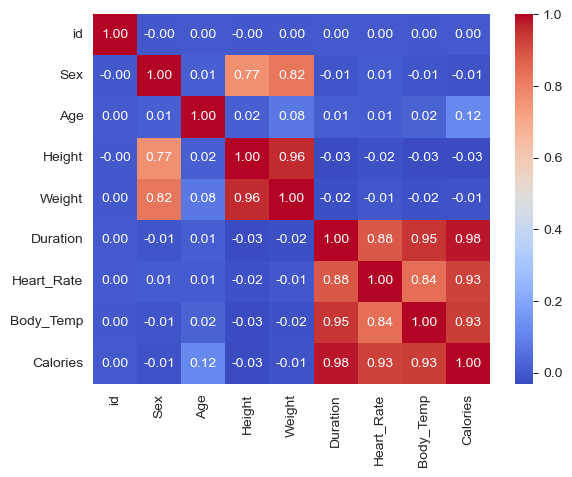

In [15]:
sns.heatmap(train_data.corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm")

- Calories Vs Duration: 0.98
- Calories Vs Heart_Rate: 0.93
- Calories Vs Body_Temp: 0.93

Age, Height and Weight have the least correlation with Calories.

### Skewness

In [16]:
train_data.skew()

id           -1.963100e-15
Sex           3.845348e-03
Age           4.363975e-01
Height        5.177712e-02
Weight        2.111939e-01
Duration      2.625895e-02
Heart_Rate   -5.668158e-03
Body_Temp    -1.022361e+00
Calories      5.391963e-01
dtype: float64

`Body_Temp` is negatively skewed. All other features doesn't show significant skewness.

### Missing Values

Most machine learning algorithms give an error when we train them on data with missing values. Therefore, it's important to identify them before deciding how to handle them (drop features or impute missing value).

In [17]:
missing_data = train_data.isnull().sum()
missing_data_per = missing_data / len(train_data) * 100
missing_data_per

id            0.0
Sex           0.0
Age           0.0
Height        0.0
Weight        0.0
Duration      0.0
Heart_Rate    0.0
Body_Temp     0.0
Calories      0.0
dtype: float64

<Axes: xlabel='None', ylabel='None'>

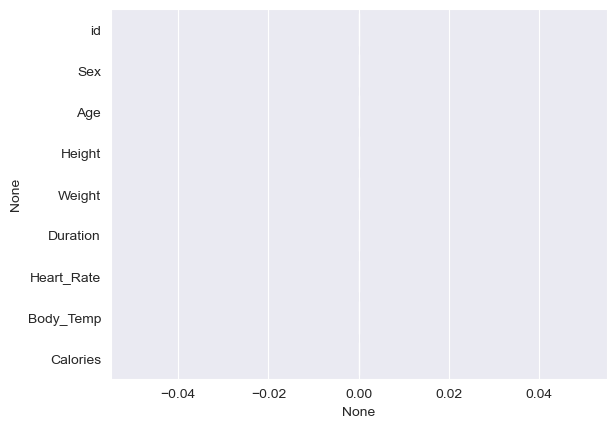

In [18]:
sns.barplot(y=missing_data_per.index,
            x=missing_data_per)

This dataset quality is good and doesn't contain any missing data. No data imputation is required.

### Numerical Features - UniVariate Analysis

<Axes: xlabel='Calories', ylabel='Count'>

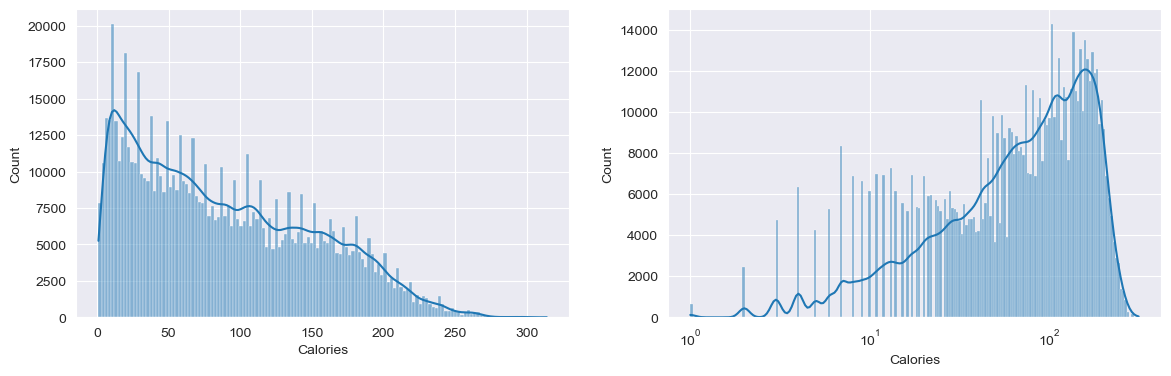

In [19]:
fig, axis = plt.subplots(1, 2, figsize = (14,4))

sns.histplot(train_data, x="Calories", kde=True, ax=axis[0])
sns.histplot(train_data, x="Calories", kde=True, ax=axis[1], log_scale=True)

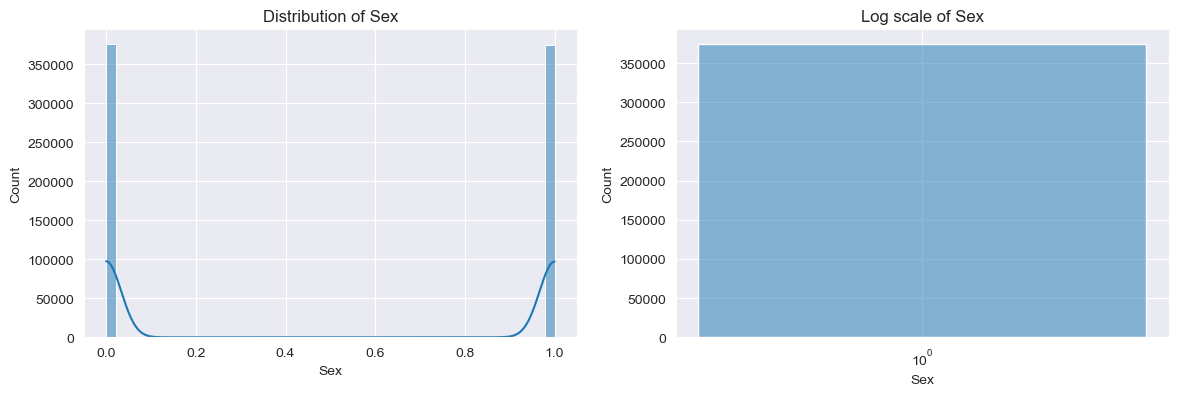

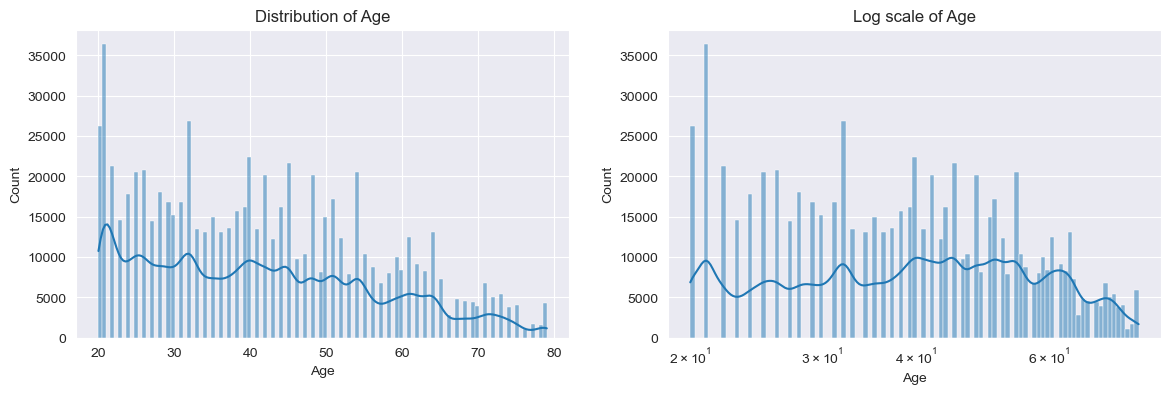

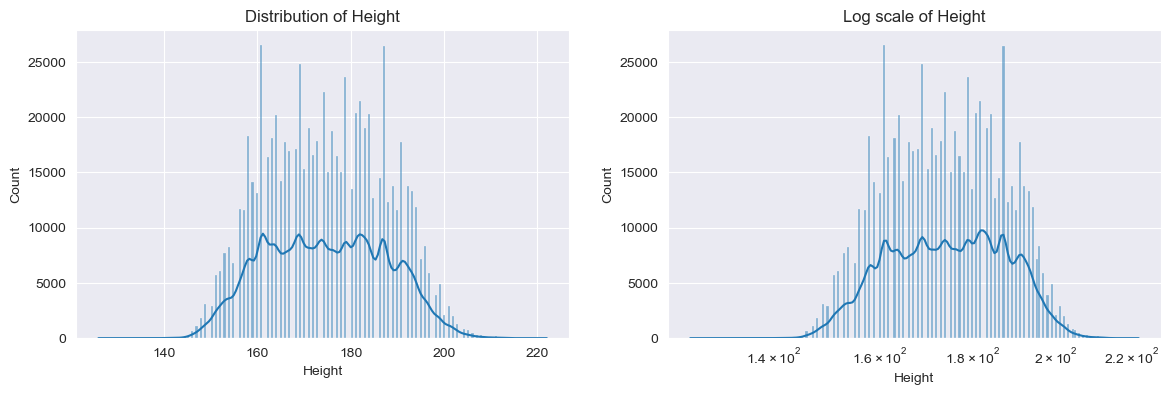

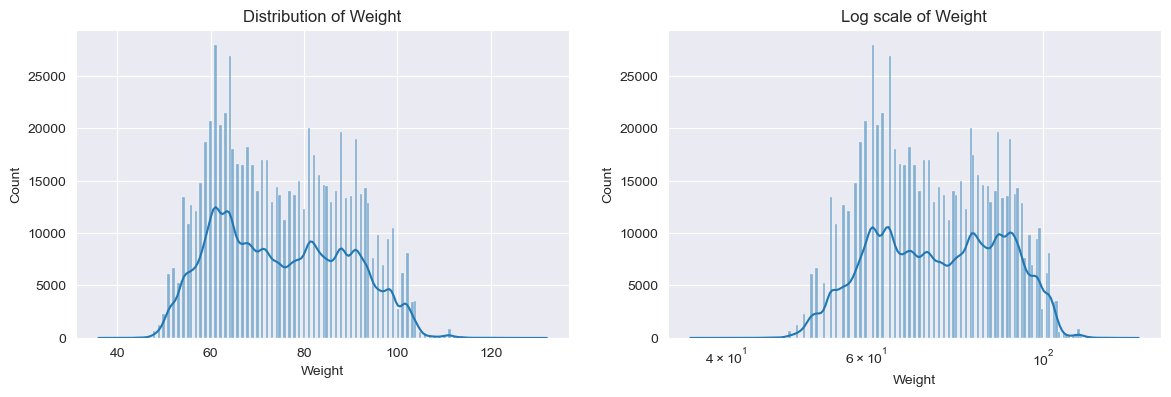

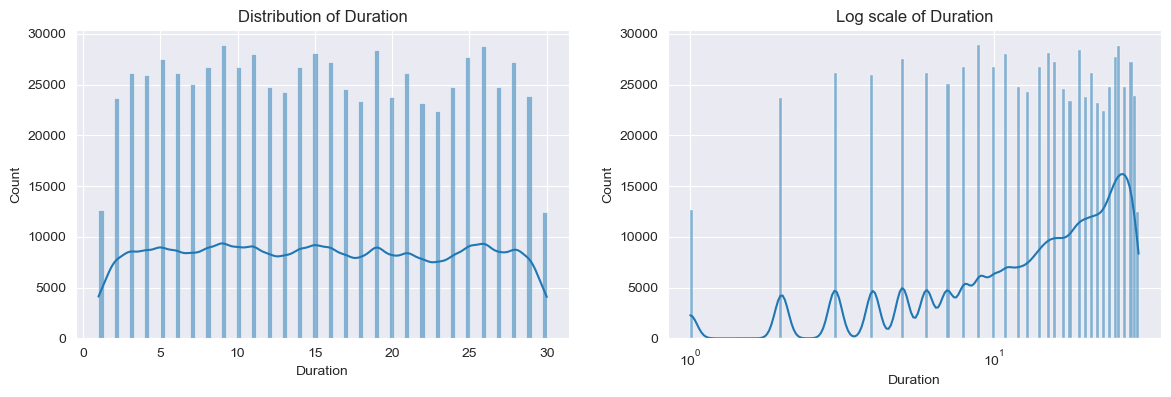

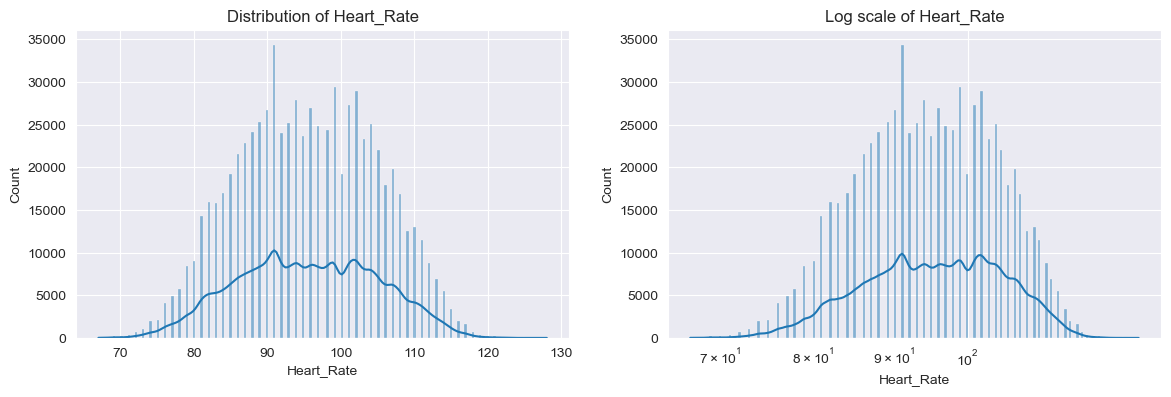

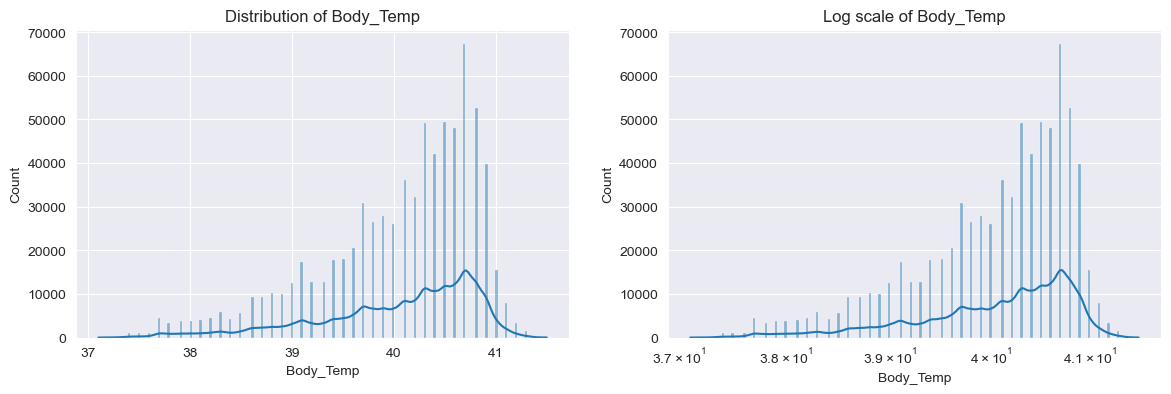

In [20]:
numCols = list(train_data.select_dtypes(exclude='object').columns)
numCols.remove("id")
numCols.remove("Calories")

for col in numCols:
    fig, axis = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(train_data, x=col, kde=True, ax=axis[0])
    sns.histplot(train_data, x=col, kde=True, ax=axis[1], log_scale=True)
    axis[0].set_title(f"Distribution of {col}")
    axis[1].set_title(f"Log scale of {col}")
    plt.show()

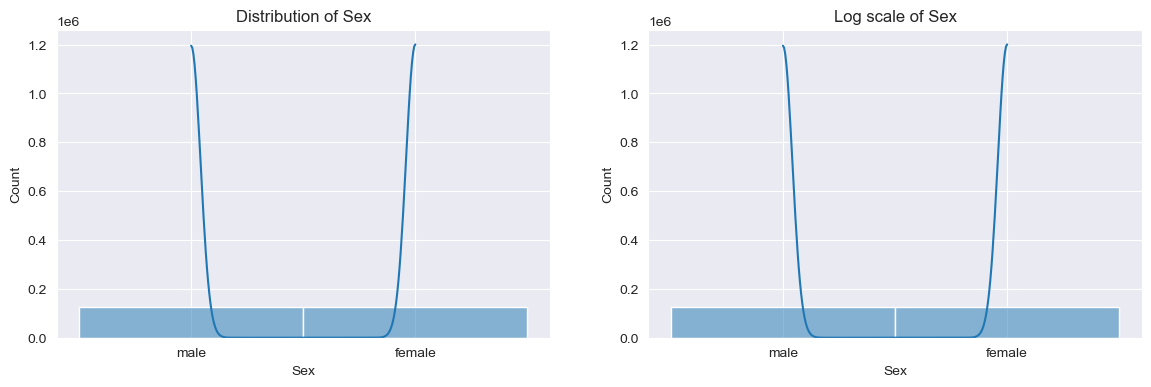

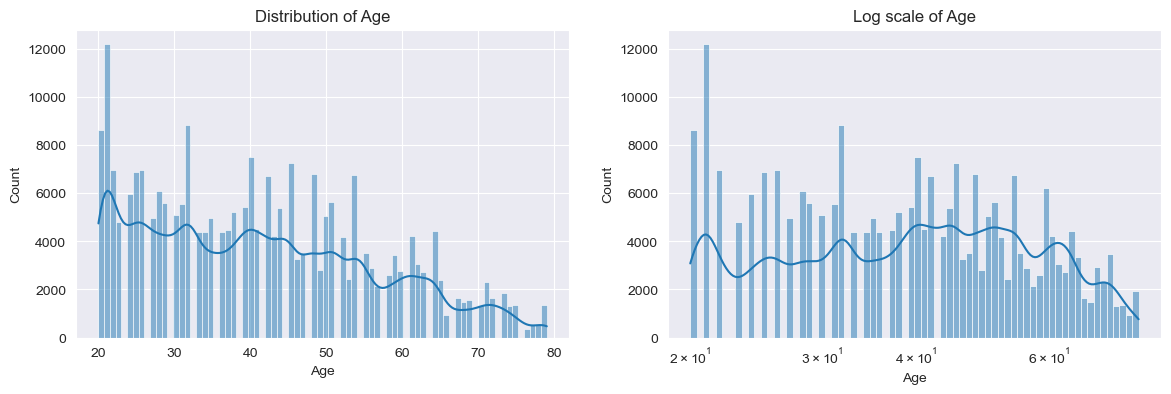

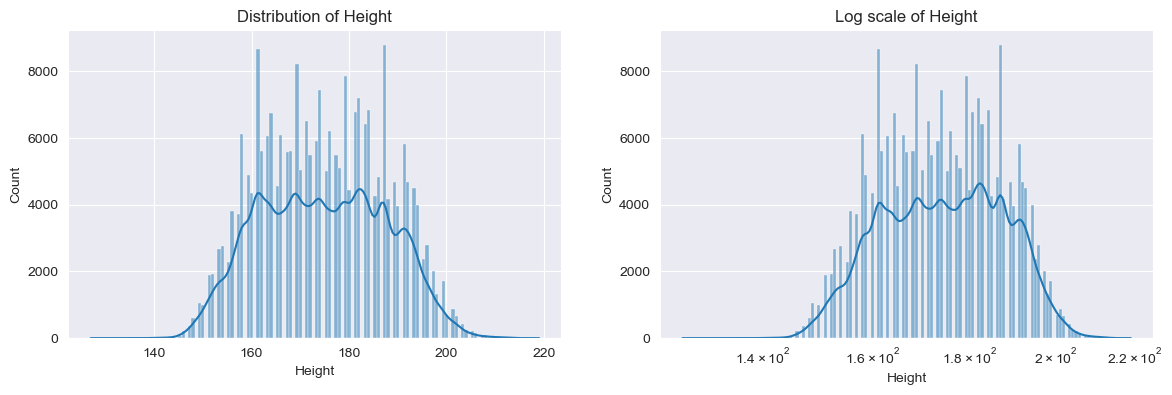

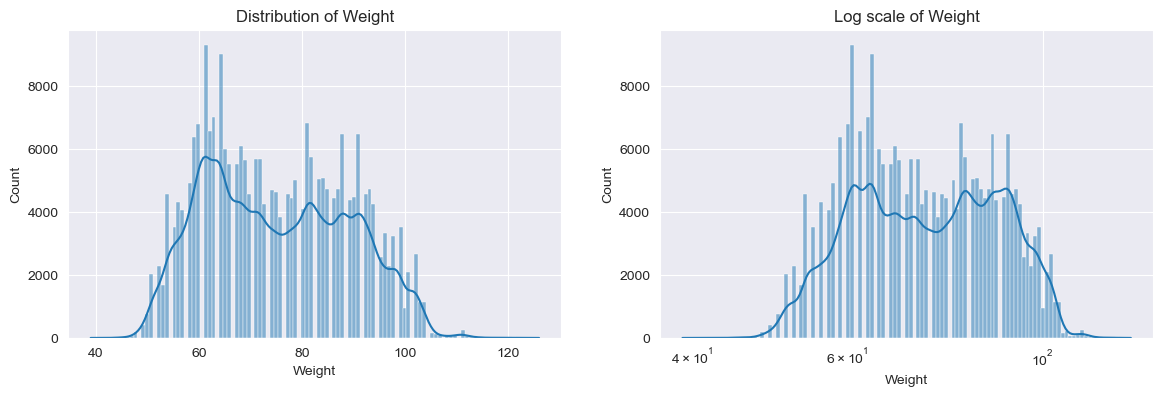

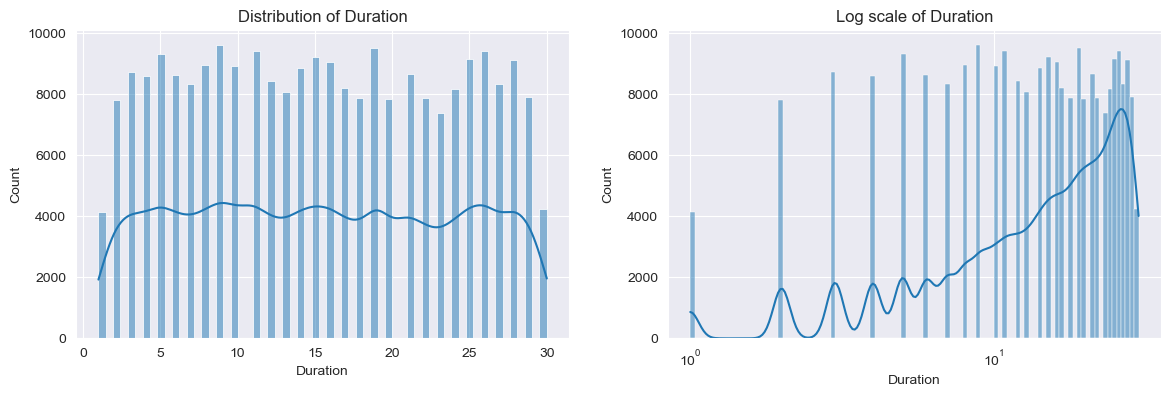

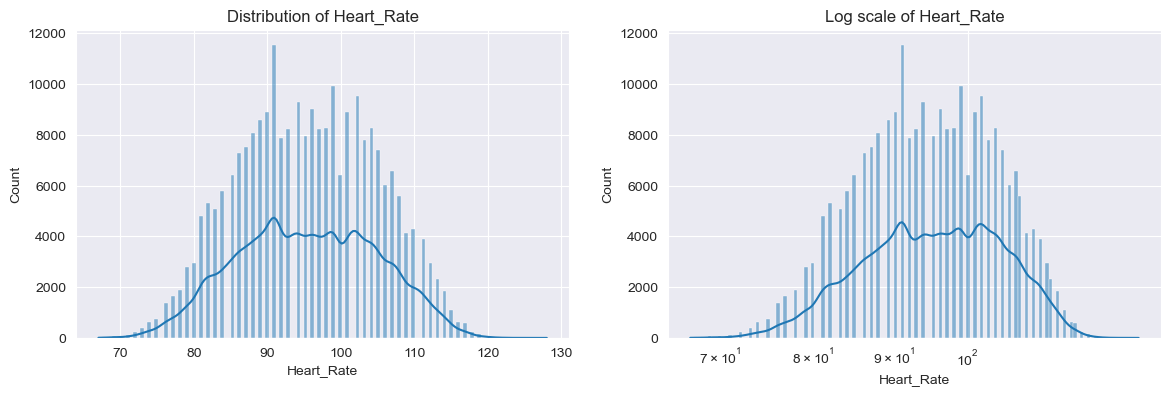

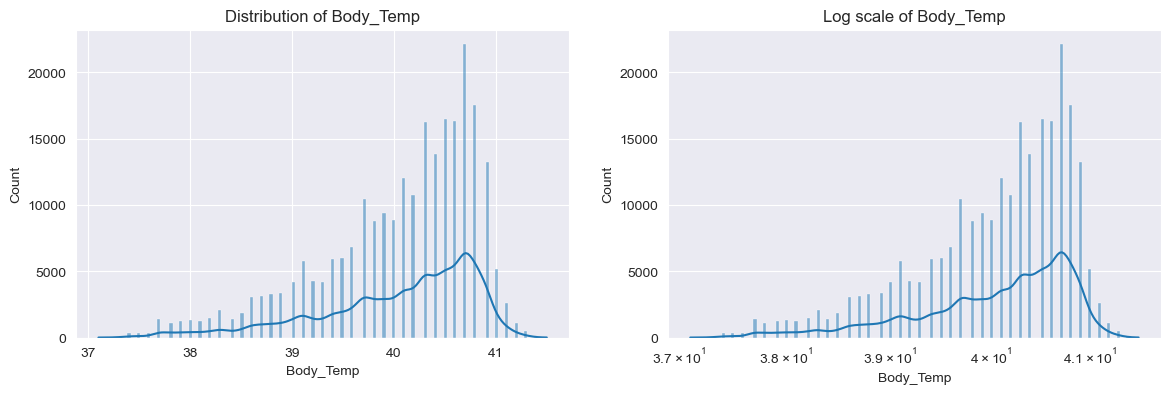

In [21]:
for col in numCols:
    fig, axis = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(test_data, x=col, kde=True, ax=axis[0])
    sns.histplot(test_data, x=col, kde=True, ax=axis[1], log_scale=True)
    axis[0].set_title(f"Distribution of {col}")
    axis[1].set_title(f"Log scale of {col}")
    plt.show()

- test dataset is symmetrical with train dataset. No extra processing required for train dataset.
- Perfect 50 / 50 gender split in both datasets — no re‑weighting needed.

### Numerical Features - Bivariate Analysis

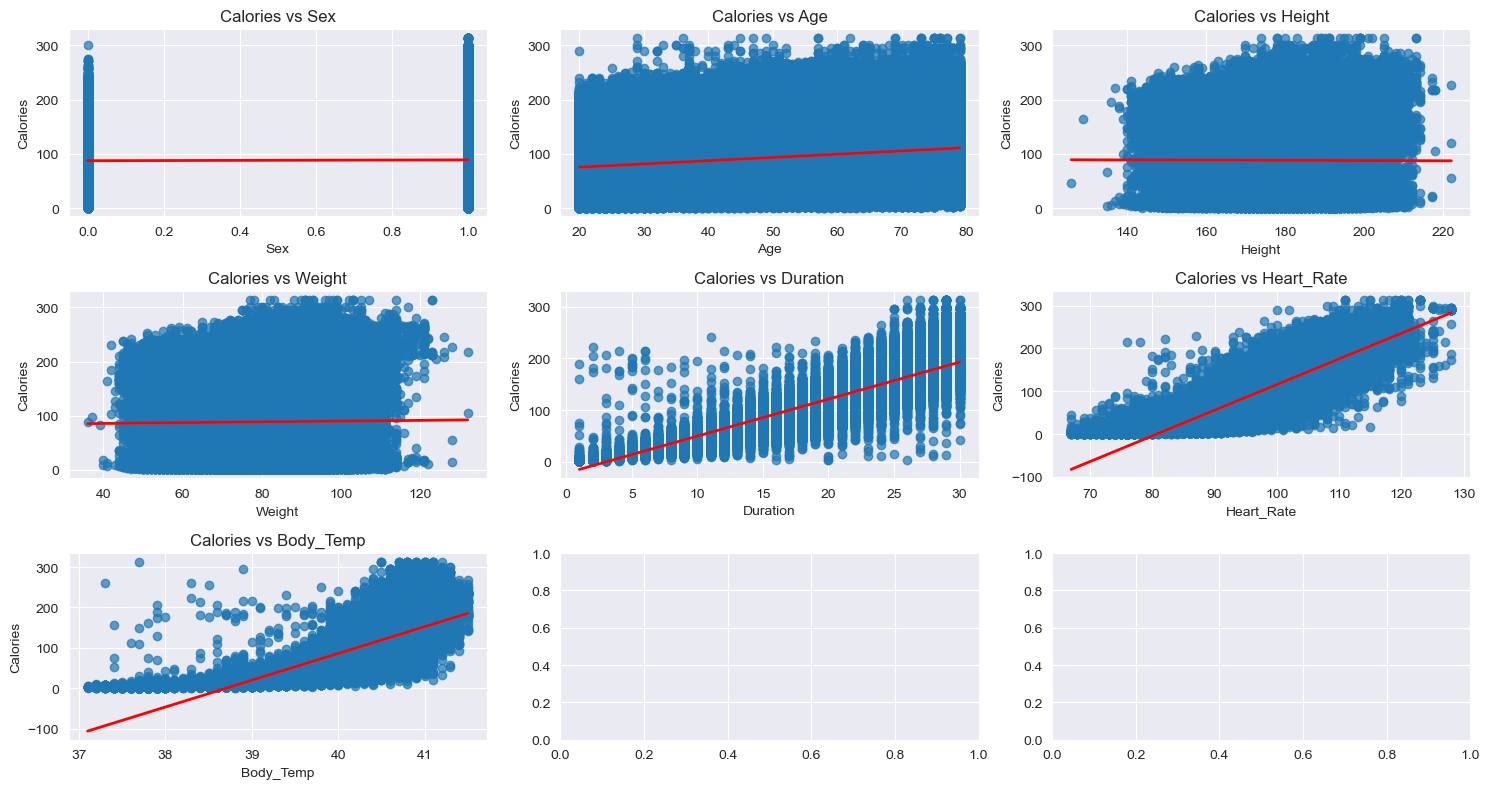

In [ ]:
fig, axis = plt.subplots(len(numCols) // 3 + 1, 3, figsize=(15, 4* (len(numCols) // 3)))
for no, col in enumerate(numCols):
    r, c = divmod(no, 3)
    sns.regplot(x=col, y="Calories", data=train_data, ax=axis[r][c], line_kws={"color": "red", "linewidth": 2}, scatter_kws={"alpha": 0.3})
    axis[r][c].set_title(f"Calories vs {col}")

plt.tight_layout()
plt.show()

C:\Users\cmodi\AppData\Local\Temp\ipykernel_2808\2035911868.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Sex", y="Calories", data=train_data, palette="pastel", inner="quartile")


<Axes: xlabel='Sex', ylabel='Calories'>

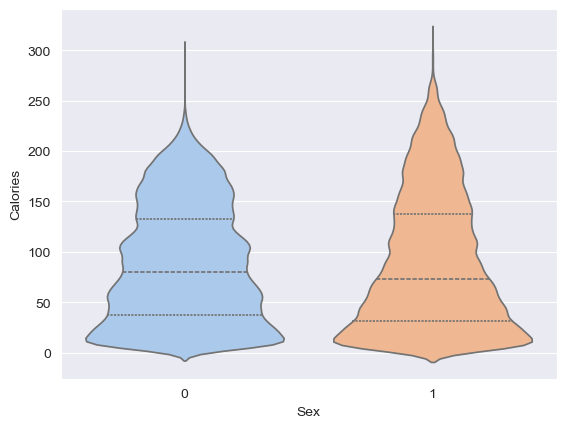

In [23]:
sns.violinplot(x="Sex", y="Calories", data=train_data, palette="pastel", inner="quartile")

- Straight line for `Duration`
- linear relation for `Heart_Rate`
- Quadratic relation for `Body_Temp` after 39C.
- Use polynomial features for non-linear models

### Feature Interactions

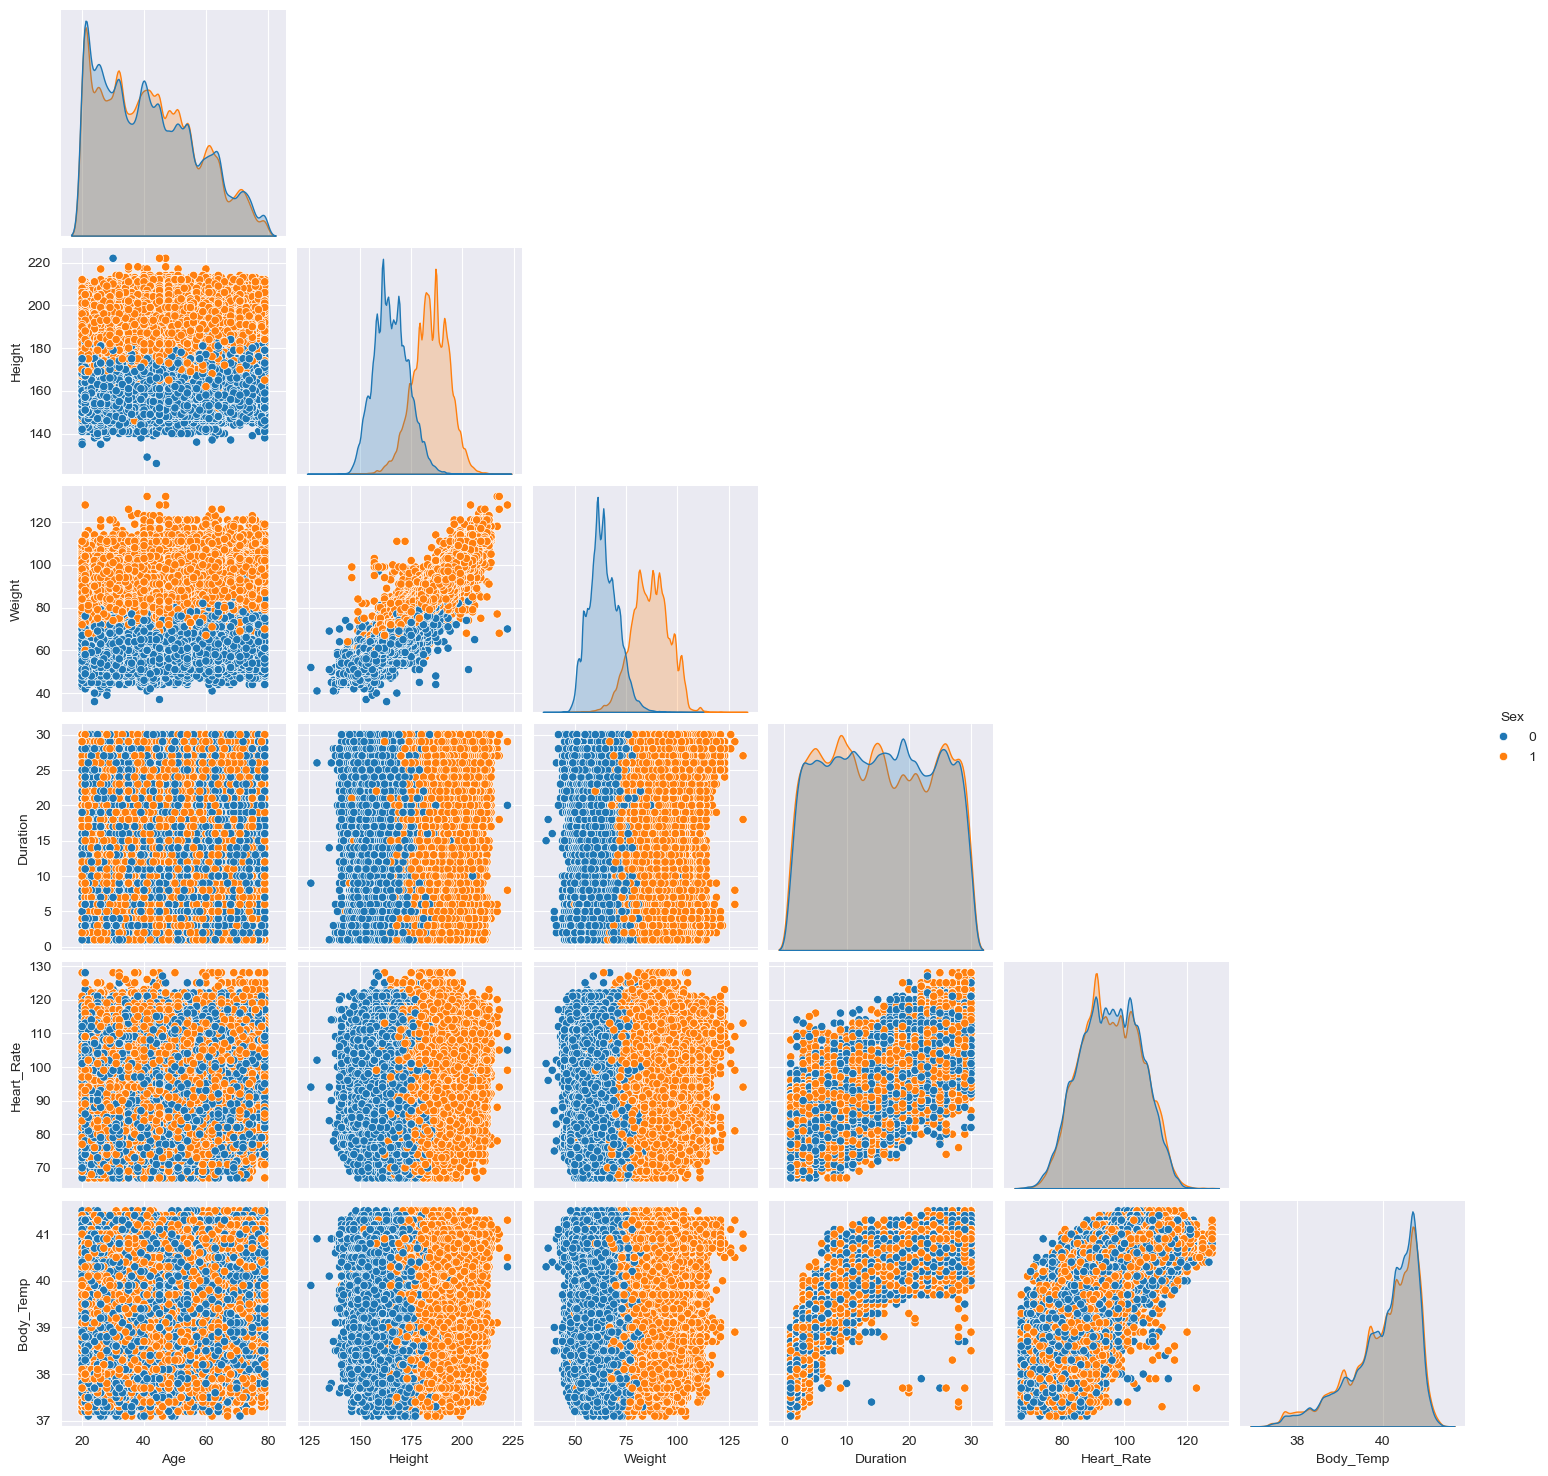

In [24]:
sns.pairplot(train_data[numCols], hue="Sex", corner=True)

No direct pattern, ensemble will work.

### Multicolinearity Check (Variance Inflation Factor)

In [25]:
cols = numCols.copy()
cols.remove("Sex")

X_vif = train_data[cols].assign(constant=1)
vif_df = pd.DataFrame({
    "feature": cols,
    "VIF"    : [variance_inflation_factor(X_vif.values, i) for i in range(len(cols))]
})

display(vif_df.sort_values("VIF", ascending=False).style.background_gradient(cmap="Reds"))

,feature,VIF
2,Weight,12.766902
1,Height,12.702162
3,Duration,8.510592
5,Body_Temp,5.434871
4,Heart_Rate,4.285830
0,Age,1.050873


`Height` & `Weight` highly collinear (VIF ≈ 13). Combine them or drop one when using linear/GLM; harmless for tree‑based methods.

### Principal Component Analysis

<Axes: xlabel='PC1', ylabel='PC2'>

c:\Users\cmodi\anaconda3\envs\dev\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\cmodi\anaconda3\envs\dev\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


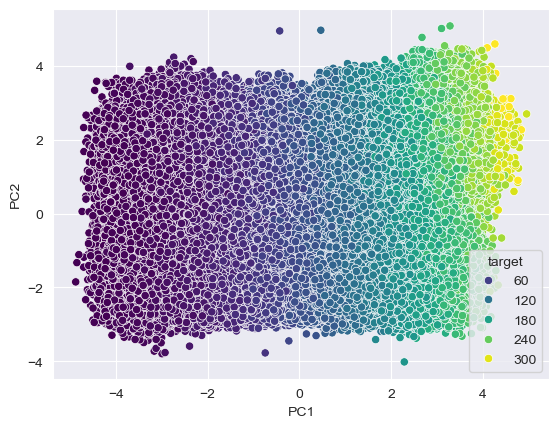

In [26]:
# 1. Scale the data (important for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)

# 2. Fit PCA on training data
pca = PCA(n_components=2)  # Choose number of components
X_train_pca = pca.fit_transform(X_train_scaled)

# 3. Visualize PCA components on training data
pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['target'] = train_data["Calories"].values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='viridis')

Calories align smoothly along PC‑1 ⇒ a single latent dimension (work‑intensity) explains most variance.

## Data Quality Summary
- Missing Values: No missing (NaN) values were found in the dataset. All columns have complete data, so no imputation is required.
- Duplicate Rows: No duplicate records are present in the dataset. Therefore, no action is needed for duplicate removal.
- Outlier Handling: Values seems to be within range. No outliers detected.
- test dataset is symmetrical with train dataset. No extra processing required for train dataset.
- Perfect 50 / 50 gender split in both datasets — no re‑weighting needed.
- `Body_Temp` is negatively skewed. All other features doesn't show significant skewness.
- `Body_Temp`, `Heat_Rate` and `Duration` are correlated with `Calories`. `Age`, `Height` and `Weight` have the least correlation with `Calories`.
- New Features Can be Added:
  - DIV_HT_WT
  - DIV_BT_DUR
  - DIV_HR_DUR
  - DIV_BT_HR
  - The metric RMSLE is the metric RMSE in the log(1+prediction) space. So perhaps the best ensemble method is to first convert predictions into log(1+prediction) space, then take a weighted average, then convert back to original space.
